<a href="https://colab.research.google.com/github/azrasm/ml-hotel-booking-analysis/blob/main/Hijerarhijski_klastering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MU Projekat 2/hotel_ociscen.csv')

In [ ]:
#uklanjanje labele i "leakage" kolona
df = df.drop(columns=["is_canceled", "reservation_status", "reservation_status_date"])

In [ ]:
#izbacujemo rezervacije gde je ukupan broj gostiju 0
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

#uklanjamo ekstremne vrijednosti
df = df[df['adr'] < 1000]

#Selekcija kolona za klastering (samo numeričke relevantne za hipoteze)
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

X = df[numerical_columns]

#Skaliranje
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Semplovanje
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=int(0.3 * X_scaled.shape[0]), replace=False)
X_sample = X_scaled[sample_indices]

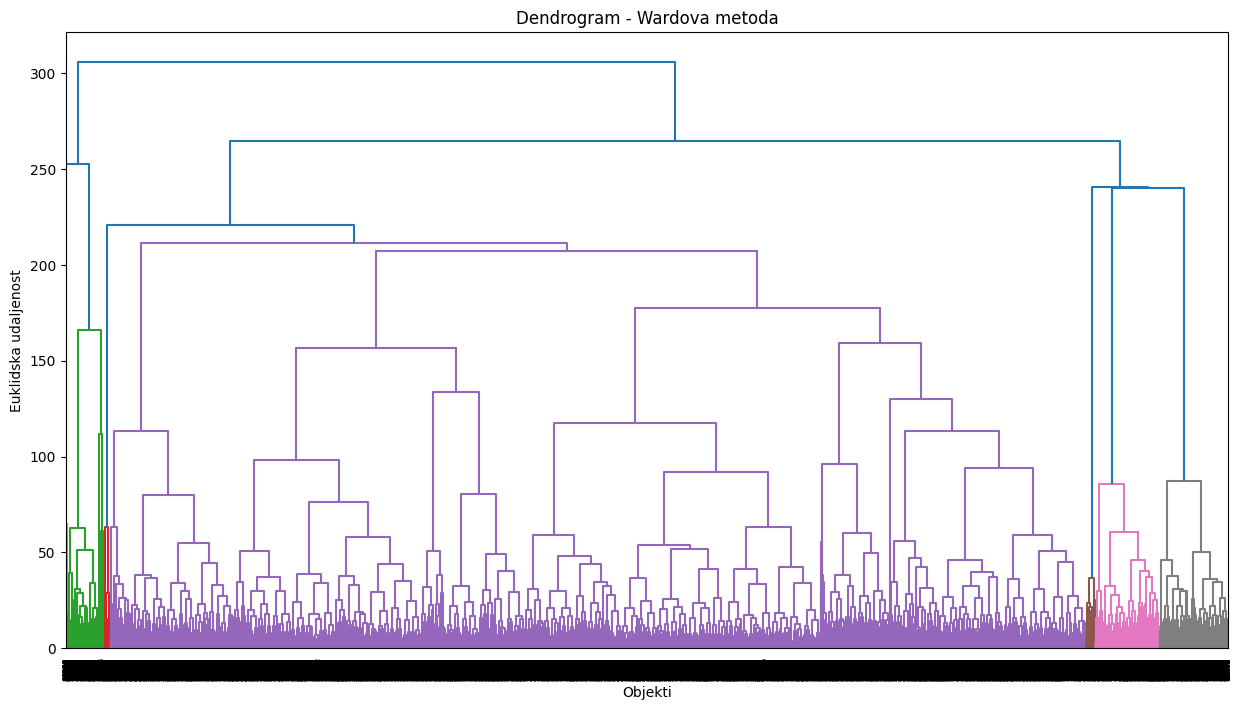

In [ ]:
plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.title("Dendrogram - Wardova metoda")
plt.xlabel("Objekti")
plt.ylabel("Euklidska udaljenost")
plt.show()

In [ ]:
agg_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = agg_model.fit_predict(X_sample)

#Silhouette Score
score = silhouette_score(X_sample, cluster_labels)
print(f"Silhouette Score nakon čišćenja: {score:.3f}")

#Kreiranje DataFrame-a za analizu
X_analysis = pd.DataFrame(X.iloc[sample_indices].values, columns=numerical_columns)
X_analysis['Cluster'] = cluster_labels

#Grupisanje i prikaz srednjih vrijednosti
cluster_summary = X_analysis.groupby('Cluster').mean()
print(cluster_summary)

Silhouette Score nakon čišćenja: 0.279
          lead_time  arrival_date_year  arrival_date_week_number  \
Cluster                                                            
0         38.928513        2016.168447                 24.796220   
1         74.347886        2016.186121                 27.852941   
2        110.185341        2016.153512                 27.162521   

         arrival_date_day_of_month  stays_in_weekend_nights  \
Cluster                                                       
0                        15.620378                 0.474938   
1                        16.298713                 0.970129   
2                        15.785281                 0.942901   

         stays_in_week_nights    adults  children    babies  \
Cluster                                                       
0                    1.475760  1.427280  0.036154  0.000000   
1                    2.538373  1.926930  0.818015  0.063189   
2                    2.534230  1.864439  0.006922  0

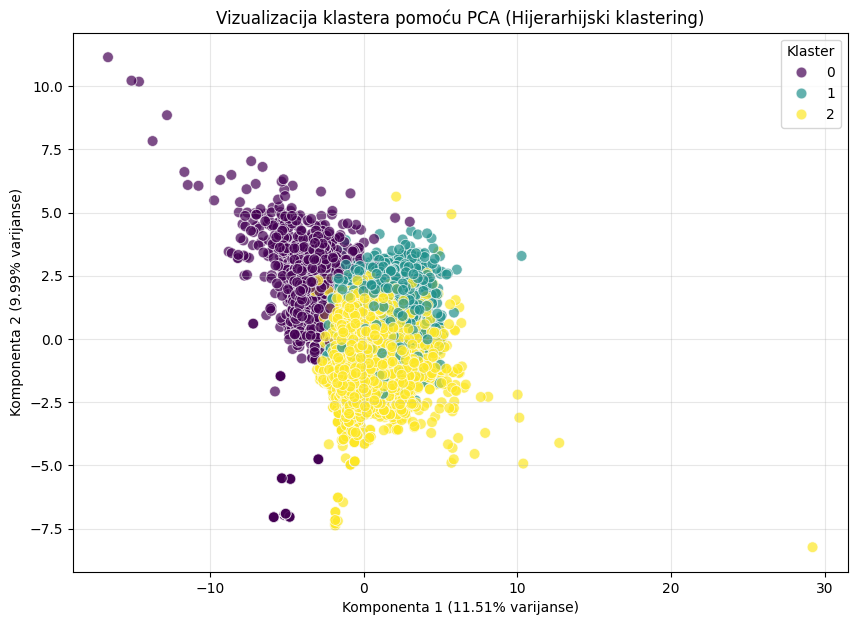

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=60, alpha=0.7)
plt.title('Vizualizacija klastera pomoću PCA (Hijerarhijski klastering)')
plt.xlabel(f'Komponenta 1 ({pca.explained_variance_ratio_[0]:.2%} varijanse)')
plt.ylabel(f'Komponenta 2 ({pca.explained_variance_ratio_[1]:.2%} varijanse)')
plt.legend(title='Klaster')
plt.grid(True, alpha=0.3)
plt.show()

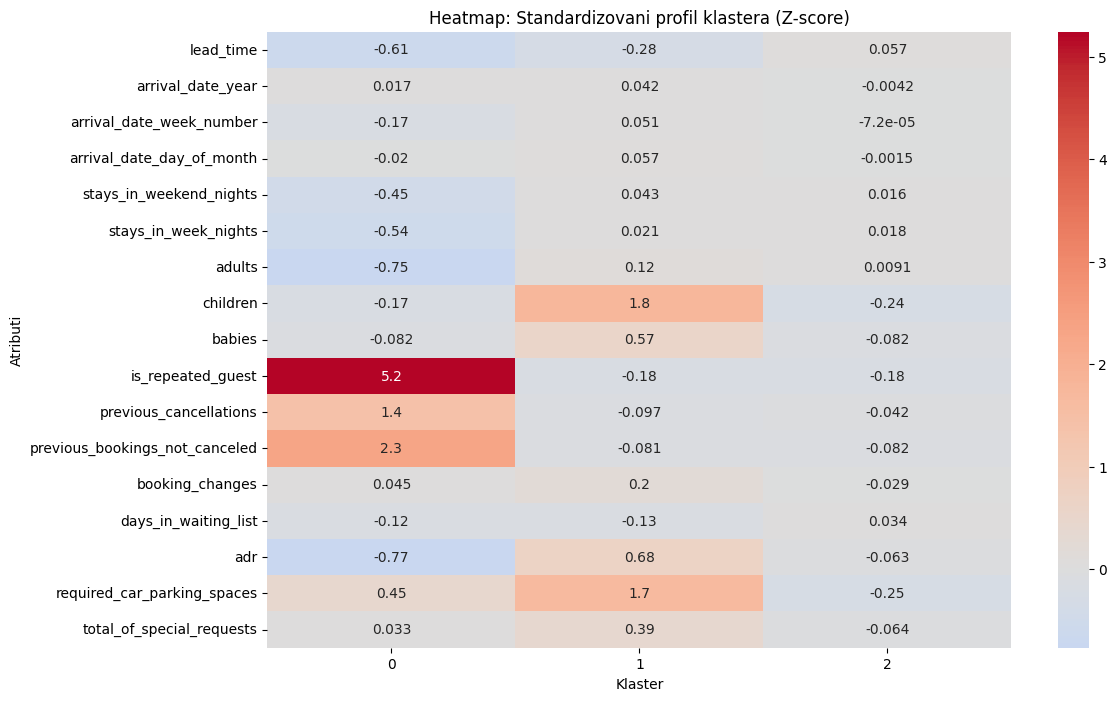

In [ ]:
#srednje vrijednosti skaliranih podataka po klasterima
scaled_analysis = pd.DataFrame(X_sample, columns=numerical_columns)
scaled_analysis['Cluster'] = cluster_labels
cluster_means_scaled = scaled_analysis.groupby('Cluster').mean()

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_scaled.T, annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap: Standardizovani profil klastera (Z-score)')
plt.ylabel('Atributi')
plt.xlabel('Klaster')
plt.show()

/tmp/ipython-input-1243720382.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='lead_time', data=X_orig_sample, ax=axes[0], palette='magma')
/tmp/ipython-input-1243720382.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='adr', data=X_orig_sample, ax=axes[1], palette='magma')
/tmp/ipython-input-1243720382.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='is_repeated_guest', data=X_orig_sample, ax=axes[2], palette='magma')


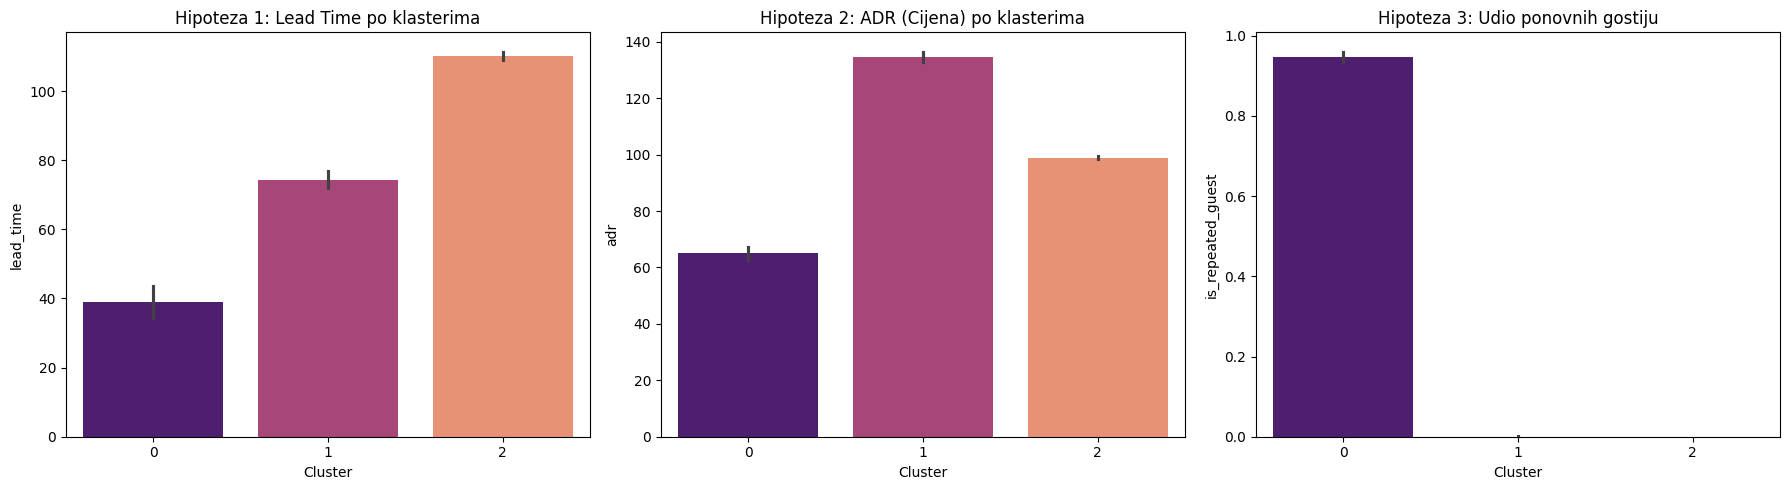

In [ ]:
X_orig_sample = X.iloc[sample_indices].copy()
X_orig_sample['Cluster'] = cluster_labels

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Hipoteza 1
sns.barplot(x='Cluster', y='lead_time', data=X_orig_sample, ax=axes[0], palette='magma')
axes[0].set_title('Hipoteza 1: Lead Time po klasterima')

#Hipoteza 2
sns.barplot(x='Cluster', y='adr', data=X_orig_sample, ax=axes[1], palette='magma')
axes[1].set_title('Hipoteza 2: ADR (Cijena) po klasterima')

#Hipoteza 3
sns.barplot(x='Cluster', y='is_repeated_guest', data=X_orig_sample, ax=axes[2], palette='magma')
axes[2].set_title('Hipoteza 3: Udio ponovnih gostiju')

plt.tight_layout()
plt.show()